Max difference: 7.6293945e-05


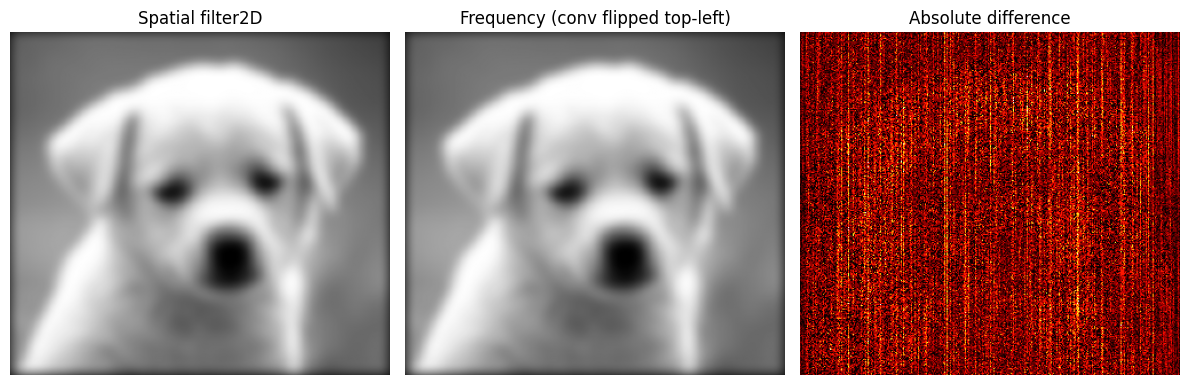

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

#load image to grayscale because convolution is easier to show on @D images
img = cv2.imread("puppy.jpg", cv2.IMREAD_GRAYSCALE)
img = img.astype(np.float32) #load float32 because FFT and convolution need floating-point precision
h, w = img.shape #store height and width

#gaussian kernel
def gaussian_kernel(size=21, sigma=5): #define 2D gaussian blur 
    #kernal size- kernal dims(must be odd) and sigma = blur strength
    ax = np.linspace(-(size//2), size//2, size) #correct evenly spaced coor centred at zero
    xx, yy = np.meshgrid(ax, ax) #produces 2D grid of x and y coor
    k = np.exp(-(xx**2 + yy**2) / (2 * sigma**2)) #apply guassian equation e^-(x^2+y^2)/(2o^2)
    return (k / np.sum(k)).astype(np.float32) #normailes kernel so pixel are preserved and converts to float32 for consistency

kernel = gaussian_kernel(21, 5) #creats 21x21 gaussian kernel
kh, kw = kernel.shape #store kernel height and width

#reference spatial result (OpenCV correlation)
#apply convolution directly in spatial domain ddepth=-1 output depth same as input
#BORDER_CONSTANT - zero-padding at image borders
blur_spatial = cv2.filter2D(img, ddepth=-1, kernel=kernel, borderType=cv2.BORDER_CONSTANT)

#prepare padded sizes for linear convolution and prevents circular convolution artifacts when using FFT
H = h + kh - 1 
W = w + kw - 1

#zero-pad image into top-left of padded array
img_pad = np.zeros((H, W), dtype=np.float32)
img_pad[:h, :w] = img

#flip kernel (convert correlation -> convolution) and place top-left
kernel_flipped = np.flipud(np.fliplr(kernel)).astype(np.float32) #fliter2D performs correlation, not covolution
#FFT multi performs convolution and flipping the kernel converts correlation into convolution
kernel_pad = np.zeros((H, W), dtype=np.float32) #padding 
kernel_pad[:kh, :kw] = kernel_flipped   #top-left placement, NO ifftshift

#FFT multiply (convolution theorem) and inverse
F = np.fft.fft2(img_pad) #computes 2D FFT of padded images
K = np.fft.fft2(kernel_pad) #computes the 2D FFT of padded kernel
#multi spectra apply inverse FFT to return spatial domain and take real part to remove numerical imaginary noise 
conv_full = np.real(np.fft.ifft2(F * K))

#crop to original image size using standard start indices
start_r = kh // 2
start_c = kw // 2
blur_frequency = conv_full[start_r:start_r + h, start_c:start_c + w].astype(np.float32)

#compare spatial v. frequency results 
diff = np.abs(blur_spatial - blur_frequency)
print("Max difference:", diff.max()) #print max error 

#Visualize
plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.title("Spatial filter2D"); plt.imshow(blur_spatial, cmap='gray'); plt.axis('off')
plt.subplot(1,3,2); plt.title("Frequency (conv flipped top-left)"); plt.imshow(blur_frequency, cmap='gray'); plt.axis('off')
plt.subplot(1,3,3); plt.title("Absolute difference"); plt.imshow(diff, cmap='hot'); plt.axis('off')
plt.tight_layout()
plt.show()